In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
sc._settings.settings._vector_friendly=True

import matplotlib.pyplot as plt 

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import os
from collections import Counter
from scipy import sparse

In [2]:
plots_dir = "metadata_plots/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
%%time
adata = sc.read_h5ad("06B_combined_scVI_raw_only.h5ad")
adata

CPU times: user 11.6 s, sys: 49.2 s, total: 1min
Wall time: 1min 9s


AnnData object with n_obs × n_vars = 2275105 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'le

### Make sure all metadata is consistent

In [4]:
adata.obs['decade'] = np.floor(adata.obs['age'] / 10)

In [5]:
Counter(adata.obs.technology)

Counter({'3prime-v3': 1409837,
         'Multiome-v1': 495859,
         '5prime-v1': 193959,
         'Dropseq': 103927,
         '3prime-v1': 40670,
         '3prime-v2': 30853})

In [6]:
Counter(adata.obs.disease)

Counter({'ND': 1192215,
         'DCM': 557813,
         'HCM': 224776,
         'pediatric HF': 91936,
         'ICM': 68709,
         'ARVC': 67369,
         'AMI': 65180,
         'NCCM': 7107})

In [7]:
Counter(adata.obs.disease_binary)

Counter({'N': 1192215, 'Y': 1082890})

In [8]:
Counter(adata.obs.study)

Counter({'Chaffin 2022': 575463,
         'ENCODE v4 (Snyder)': 469672,
         'Reichart 2022': 442708,
         'Koenig 2022': 193959,
         'Kuppe 2022': 136977,
         'Hill 2022': 109283,
         'Penn': 103927,
         'Simonson 2023': 94366,
         'Litvinukova 2020': 81893,
         'Sim 2021': 40670,
         'Kanemaru 2023': 26187})

In [9]:
Counter(adata.obs.sex)

Counter({'male': 1408345, 'female': 866760})

In [10]:
Counter(adata.obs.age_group)

Counter({'middle': 1076181, 'old': 708547, 'young': 421738, 'fetal': 68639})

In [11]:
Counter(adata.obs.tech_plus_study)

Counter({'3prime-v3_Chaffin 2022': 575463,
         'Multiome-v1_ENCODE v4 (Snyder)': 469672,
         '3prime-v3_Reichart 2022': 442708,
         '5prime-v1_Koenig 2022': 193959,
         '3prime-v3_Kuppe 2022': 136977,
         '3prime-v3_Hill 2022': 109283,
         'Dropseq_Penn': 103927,
         '3prime-v3_Simonson 2023': 94366,
         '3prime-v3_Litvinukova 2020': 51040,
         '3prime-v1_Sim 2021': 40670,
         '3prime-v2_Litvinukova 2020': 30853,
         'Multiome-v1_Kanemaru 2023': 26187})

In [12]:
adata.obs['final_cell_type'] = adata.obs['v2_scvi_cell_type']

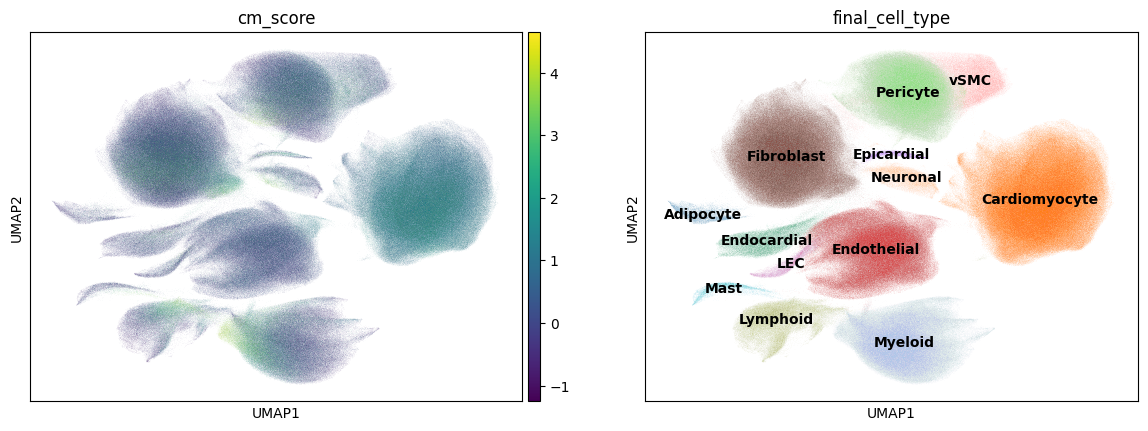

CPU times: user 12.6 s, sys: 379 ms, total: 13 s
Wall time: 12.8 s


In [13]:
%%time
sc.pl.umap(adata, color = ["cm_score", "final_cell_type"], legend_loc = "on data")

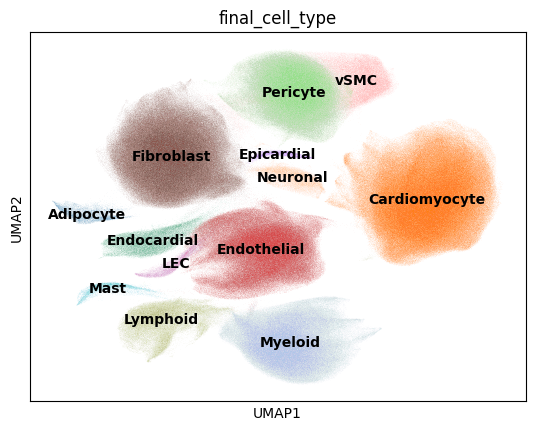

In [15]:
sc.pl.umap(adata, color = ['final_cell_type'], legend_loc = "on data")

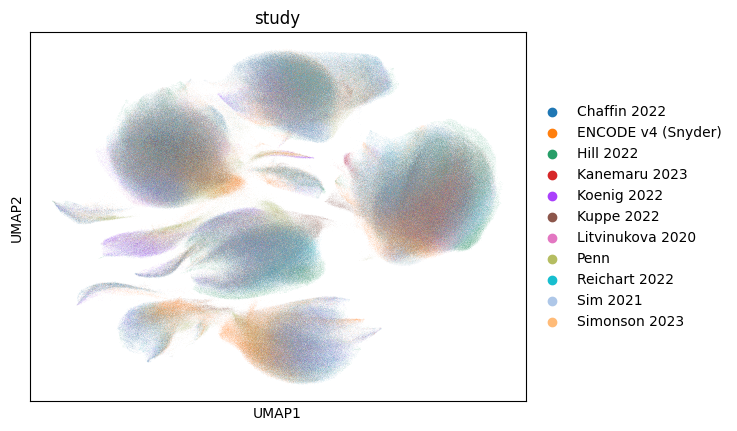

In [16]:
sc.pl.umap(adata, color = ['study'])

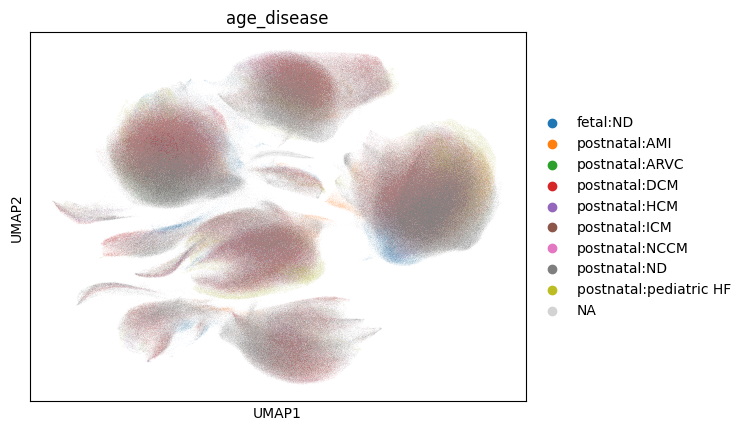

In [17]:
sc.pl.umap(adata, color = ['age_disease'])

In [18]:
adata.obs['cell_type_plus_subcluster'] = adata.obs['final_cell_type'].astype(str) + ":" + adata.obs['subcluster'].astype(str)

In [19]:
#Counter(adata.obs['cell_type_plus_subcluster'])

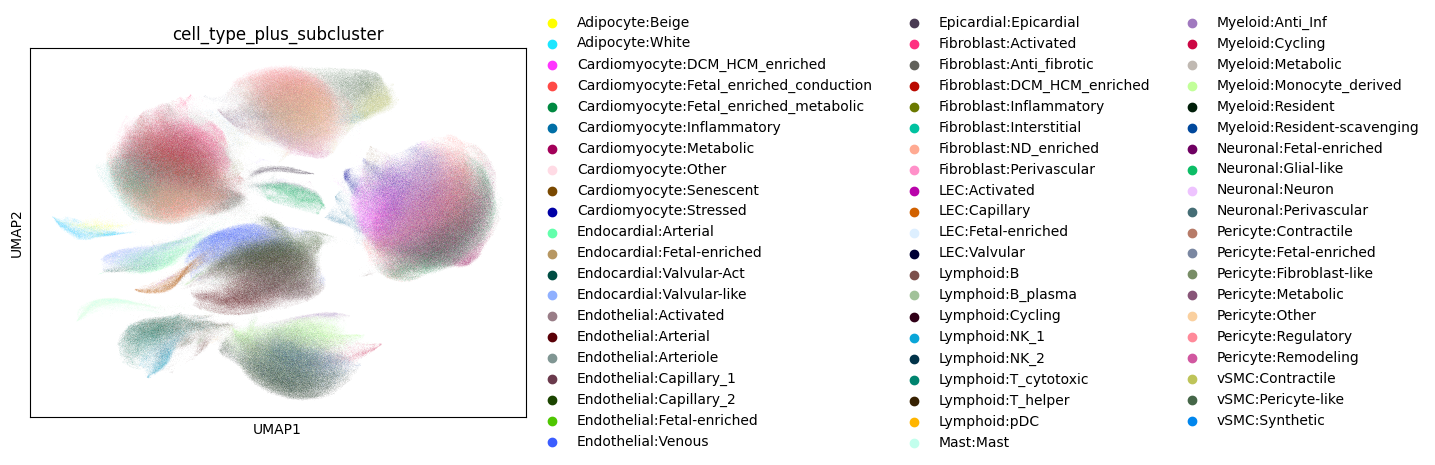

In [20]:
sc.pl.umap(adata, color = ['cell_type_plus_subcluster'])

### Save the adata for UCSC

In [21]:
adata.obs.columns

Index(['age', 'donor_id', 'sex', 'region', 'cell_type', 'disease',
       'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei',
       'barcode', 'sample_id', 'age_status', 'tech_plus_study',
       'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels',
       'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2',
       'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI',
       'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb',
       'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0',
       '

In [22]:
# drop many metadata columns
adata.obs = adata.obs.drop(columns = ['region', 'leiden0.1', 'leiden1.75', 'leiden2.0', 'decade', '_scvi_batch', '_scvi_labels',
                                     'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type',
                                     'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 
                                     'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
                                     'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 
                                     'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 
                                      'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb',
                                     "subcluster", "age_disease", "cell_or_nuclei", "cell_type", "barcode"])

### rather than using scVI-corrected; alternatively, include the log10 counts as adata.X

In [23]:
%%time
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

CPU times: user 52.6 s, sys: 2min 57s, total: 3min 49s
Wall time: 3min 27s


In [25]:
#adata.X.sum(axis = 1)

In [26]:
%%time
adata.write("06C_final_adata_for_UCSC.h5ad")

CPU times: user 21.7 s, sys: 1min 14s, total: 1min 36s
Wall time: 1min 48s
